# Imports and definitions

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import copy

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)


In [2]:
import sys
from dotenv import load_dotenv
load_dotenv()

if 'google.colab' in sys.modules:
    eval_loc = os.environ['GDRIVE_EVAL_DATA_DIR']
    from google.colab import drive
    drive.mount('/content/gdrive')
elif sys.platform == 'win32':
    eval_loc = os.environ['WINDOWS_EVAL_DATA_DIR']
else:
    eval_loc = os.environ['WSL_EVAL_DATA_DIR']
print(eval_loc)

/mnt/g/My Drive/Colab Notebooks/data/grad_student_eval/


## Definitions

In [3]:
from utils import clean_award_data, is_close, get_provider, get_size
provider_colors = {'Anthropic': '#D97706', 'Gemini': '#2563EB', 'OpenAI': '#16A34A'}

# Evals

## Golden Globes

### Load data

In [4]:
gg_golden_data = (pd.read_csv(eval_loc + '/picture/golden_set_gg_picture.tsv', sep = '\t')
                    .query('year >=2000 and award in ("Best Motion Picture - Drama", "Best Motion Picture - Musical or Comedy")')
                    )


In [5]:
picture_loc = eval_loc + 'picture/'
gg_data = {}
gg_data['haiku4.5'] = pd.read_csv(picture_loc + 'claude_haiku_4.5_gg_picture_y6.tsv', sep = '\t')
gg_data['sonnet4.5'] = pd.read_csv(picture_loc + 'claude_sonnet_4.5_gg_picture_y6.tsv', sep = '\t')
gg_data['opus4.5'] = pd.read_csv(picture_loc + 'claude_opus_4.5_gg_picture_y6.tsv', sep = '\t')
gg_data['opus4.6'] = pd.read_csv(picture_loc + 'claude_opus_46_gg_picture_y6.tsv', sep = '\t')
gg_data['fast3'] = pd.read_csv(picture_loc + 'gemini_fast_3_gg_picture_y6_sample1.tsv', sep = '\t')
#gg_data['fast3_2'] = pd.read_csv(picture_loc + 'gemini_fast_3_gg_picture_y6_sample2.tsv', sep = '\t')
gg_data['thinking3'] = pd.read_csv(picture_loc + 'gemini_thinking_3_gg_picture_y6.tsv', sep = '\t')
gg_data['pro3.1'] = pd.read_csv(picture_loc + 'gemini_pro_31_gg_picture_y6.tsv', sep = '\t')
gg_data['gpt_mini_5'] = pd.read_csv(picture_loc + 'gpt_mini_5_gg_picture_y6.tsv', sep = '\t')
gg_data['gpt_5.2'] = pd.read_csv(picture_loc + 'gpt_52_gg_picture_y6.tsv', sep = '\t')

for model, df in gg_data.items():
    df['llm_result'] = True

In [6]:
for key, df in gg_data.items():
    gg_data[key] = clean_award_data(df)
gg_golden_data = clean_award_data(gg_golden_data)

In [7]:
gg_merges = {}
for model in ['haiku4.5', 'sonnet4.5', 'opus4.6', 'gpt_5.2', 'pro3.1']:
    gg_merges[model] = gg_golden_data.merge(gg_data[model], on = ('year', 'status', 'award', 'title'), how = 'left')
    gg_merges[model]['model'] = model
    
for model in ['opus4.5','thinking3', 'fast3', 'gpt_mini_5']:
    shift_df = gg_data[model].copy()
    shift_df['year'] = shift_df['year'] - 1
    gg_merges[model] = gg_golden_data.merge(shift_df, on = ('year', 'status', 'award', 'title'), how = 'left')
    gg_merges[model]['model'] = model

### Eval

In [8]:
gg_evals = {}
for model, merge_df in gg_merges.items():
    if model.endswith('_shift'):
        gg_evals[model] = merge_df.query('year >= 2001')['llm_result'].sum() / len(merge_df)
    else:
        gg_evals[model] = merge_df['llm_result'].sum() / len(merge_df)


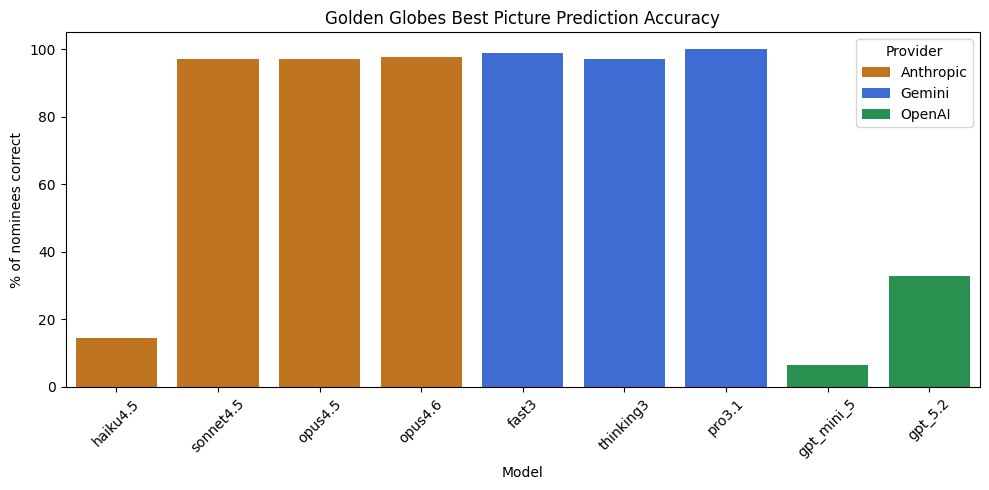

In [9]:
gg_plot_df = pd.DataFrame(list(gg_evals.items()), columns=['model', 'accuracy'])
gg_plot_df['accuracy'] = gg_plot_df['accuracy'] *  100


gg_plot_df['provider'] = gg_plot_df['model'].apply(get_provider)
gg_plot_df['size'] = gg_plot_df['model'].apply(get_size)
gg_plot_df = gg_plot_df.sort_values(['provider', 'size', 'model'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=gg_plot_df, x='model', y='accuracy', hue='provider', palette=provider_colors, dodge=False, ax=ax)
ax.set_ylabel('% of nominees correct')
ax.set_xlabel('Model')
ax.set_title('Golden Globes Best Picture Prediction Accuracy')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Provider')

plt.tight_layout()
plt.show()
fig.savefig('gg.png', dpi=600, bbox_inches ='tight')

Missed two films because there were 7 nominees rather than 5

In [10]:
gg_merges['sonnet4.5'].query ('year == 2007 and award == "best picture - drama"')

,year,status,award,title,llm_result,model
168,2007,winner,best picture - drama,atonement,True,sonnet4.5
169,2007,nominated,best picture - drama,there will be blood,NaN,sonnet4.5
170,2007,nominated,best picture - drama,no country for old men,NaN,sonnet4.5
171,2007,nominated,best picture - drama,michael clayton,True,sonnet4.5
172,2007,nominated,best picture - drama,the great debaters,True,sonnet4.5
173,2007,nominated,best picture - drama,eastern promises,True,sonnet4.5
174,2007,nominated,best picture - drama,american gangster,True,sonnet4.5


In [11]:
missed_movies = pd.concat([df.loc[df['llm_result'].isnull()] for df in gg_merges.values() ] )
missed_movies['title'].value_counts().head(10)

title
war horse                    4
the tourist                  4
there will be blood          4
no country for old men       4
michael clayton              4
good night, and good luck    4
million dollar baby          4
sunshine                     4
air                          3
barbie                       3
Name: count, dtype: int64

## Box office data

### Canonical data
Load TMDB movie box office data
Need to join the eval to the input list

In [12]:
tmdb_pdf = pd.read_csv(eval_loc + 'boxoffice/tmdb_2000_2024.csv', sep = ',')
money_cols = ['worldwide', 'domestic', 'foreign']
input_pdf = pd.read_csv(eval_loc + 'boxoffice/grad_student_boxoffice_input.tsv', sep = '\t')
input_pdf = clean_award_data(input_pdf)

In [13]:
eval_pdf = tmdb_pdf[['Release Group', '$Worldwide', '$Domestic', '$Foreign', 'Year']]
eval_pdf = clean_award_data(eval_pdf)
eval_pdf.columns = ['title', 'worldwide', 'domestic', 'foreign', 'year']
eval_pdf = eval_pdf.merge(input_pdf, on = ['title', 'year'], how = 'inner')
for col in money_cols:
  eval_pdf.loc[:,col] = (eval_pdf[col] / 1e6).round(decimals=3)
  eval_pdf.loc[:,col + '_round'] = eval_pdf[col].round(decimals=0)
eval_pdf = eval_pdf.convert_dtypes()

### Load LLM data

In [14]:
data = {}
data['haiku4.5'] = pd.read_csv(eval_loc + 'boxoffice/claude_haiku_4.5_boxoffice_y6.tsv', sep = '\t')
data['sonnet4.5'] = pd.read_csv(eval_loc + 'boxoffice/claude_sonnet_4.5_boxoffice_y6.tsv', sep = '\t')
data['opus4.5'] = pd.read_csv(eval_loc + 'boxoffice/claude_opus_4.5_boxoffice_y6.tsv', sep = '\t')
data['opus4.6'] = pd.read_csv(eval_loc + 'boxoffice/claude_opus_4.6_boxoffice_y6.tsv', sep = '\t')
#data['opus4.5_2'] = pd.read_csv(eval_loc + 'boxoffice/claude_opus_4.5_boxoffice_y6_sample2.tsv', sep = '\t')
data['fast3'] = pd.read_csv(eval_loc + 'boxoffice/gemini_fast_3_boxoffice_y6.tsv', sep = '\t')
data['thinking3'] = pd.read_csv(eval_loc + 'boxoffice/gemini_thinking_research_3_boxoffice_y6.tsv', sep = '\t')
data['pro3.1'] = pd.read_csv(eval_loc + 'boxoffice/gemini_pro_3_boxoffice_y6.tsv', sep = '\t')
data['pro3.1_babysat'] = pd.read_csv(eval_loc + 'boxoffice/gemini_pro_babysat_3_boxoffice_y6.tsv', sep = '\t')
data['gpt_5.2'] = pd.read_csv(eval_loc + 'boxoffice/gpt_52_boxoffice_y6.tsv', sep = '\t')

In [15]:
for key, df in data.items():
    df = clean_award_data(df)
    for col in money_cols:
        df.loc[:, col] = df[col].round(decimals = 3)
        df.loc[:, col + '_round'] = df[col].round(decimals = 0).astype(pd.Int64Dtype())
    data[key] = df.convert_dtypes()

In [16]:
boxoffice_merges = {}
for model in data:
    boxoffice_merges[model] = data[model].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes = ('_student', '_eval'))

### Eval

In [17]:
stat_default = {'rounded':  {col: 0.0 for col in money_cols},
                'close_1%': {col: 0.0 for col in money_cols},
                'close_5%': {col: 0.0 for col in money_cols}}
boxoffice_evals = {model: copy.deepcopy(stat_default) for model in boxoffice_merges}

for model, merge_df in boxoffice_merges.items():
    for col in money_cols:
        boxoffice_evals[model]['rounded'][col] = (merge_df[col + '_round_student'] == merge_df[col + '_round_eval']).sum() / len(merge_df)
        boxoffice_evals[model]['close_1%'][col] = is_close(merge_df[col + '_student'], merge_df[col + '_eval'], 0.01).sum() / len(merge_df)
        boxoffice_evals[model]['close_5%'][col] = is_close(merge_df[col + '_student'], merge_df[col + '_eval']).sum() / len(merge_df)
boxoffice_evals['gpt_5_mini'] = copy.deepcopy(stat_default)
for col in money_cols:
    boxoffice_evals['gpt_5_mini']['rounded'][col] = 0



In [18]:
data_for_plot = []
for model, metrics in boxoffice_evals.items():
    for metric_name, categories in metrics.items():
        for category, value in categories.items():
            data_for_plot.append({'model': model, 'metric': metric_name, 'category': category, 'value': value})

boxoffice_plot_df = pd.DataFrame(data_for_plot)
boxoffice_plot_df['value'] *= 100
boxoffice_plot_df['provider'] = boxoffice_plot_df['model'].apply(get_provider)
boxoffice_plot_df['color'] = boxoffice_plot_df['provider'].map(provider_colors)
boxoffice_plot_df['size'] = boxoffice_plot_df['model'].apply(get_size)
boxoffice_plot_df = boxoffice_plot_df.sort_values(['provider', 'size'])
# Order metrics for consistent plotting
metric_order = ['rounded', 'close_1%', 'close_5%']
boxoffice_plot_df['metric'] = pd.Categorical(boxoffice_plot_df['metric'], categories=metric_order, ordered=True)


In [19]:
boxoffice_summary_pdf = boxoffice_plot_df.groupby(['model', 'provider', 'size'])['value'].mean().reset_index().sort_values(['provider', 'size'])
boxoffice_summary_pdf

,model,provider,size,value
3,haiku4.5,Anthropic,0,5.195473
8,sonnet4.5,Anthropic,1,76.594650
4,opus4.5,Anthropic,2,73.713992
5,opus4.6,Anthropic,2,75.000000
0,fast3,Gemini,0,2.469136
9,thinking3,Gemini,1,88.580247
6,pro3.1,Gemini,Other,15.637860
7,pro3.1_babysat,Gemini,Other,84.002058
2,gpt_5_mini,OpenAI,0,0.000000
1,gpt_5.2,OpenAI,2,5.452675


### Graph

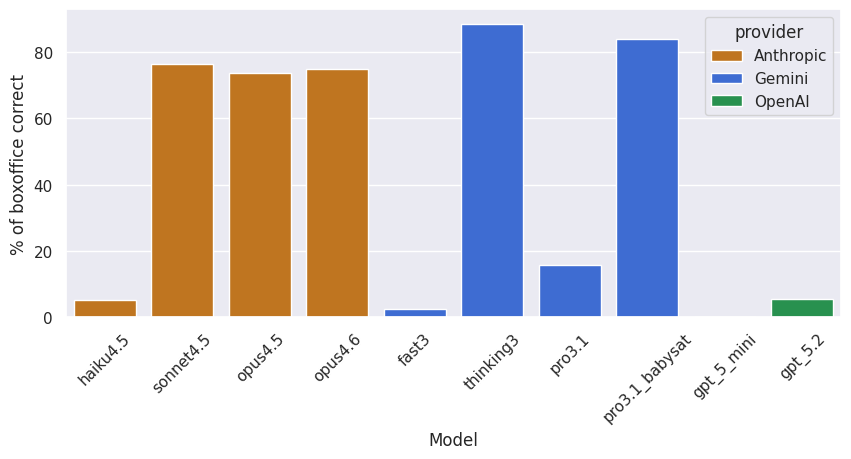

In [85]:
sns.set(font_scale=1)
fig, ax = plt.subplots(1, figsize = [10, 4])

sns.barplot(boxoffice_summary_pdf, x = 'model', y = 'value', hue = 'provider',palette=provider_colors,)
ax.tick_params(axis='x', rotation=45)
plt.ylabel('% of boxoffice correct')
plt.xlabel('Model')
fig.savefig('boxoffice_summary.png', dpi = 600, bbox_inches = 'tight')

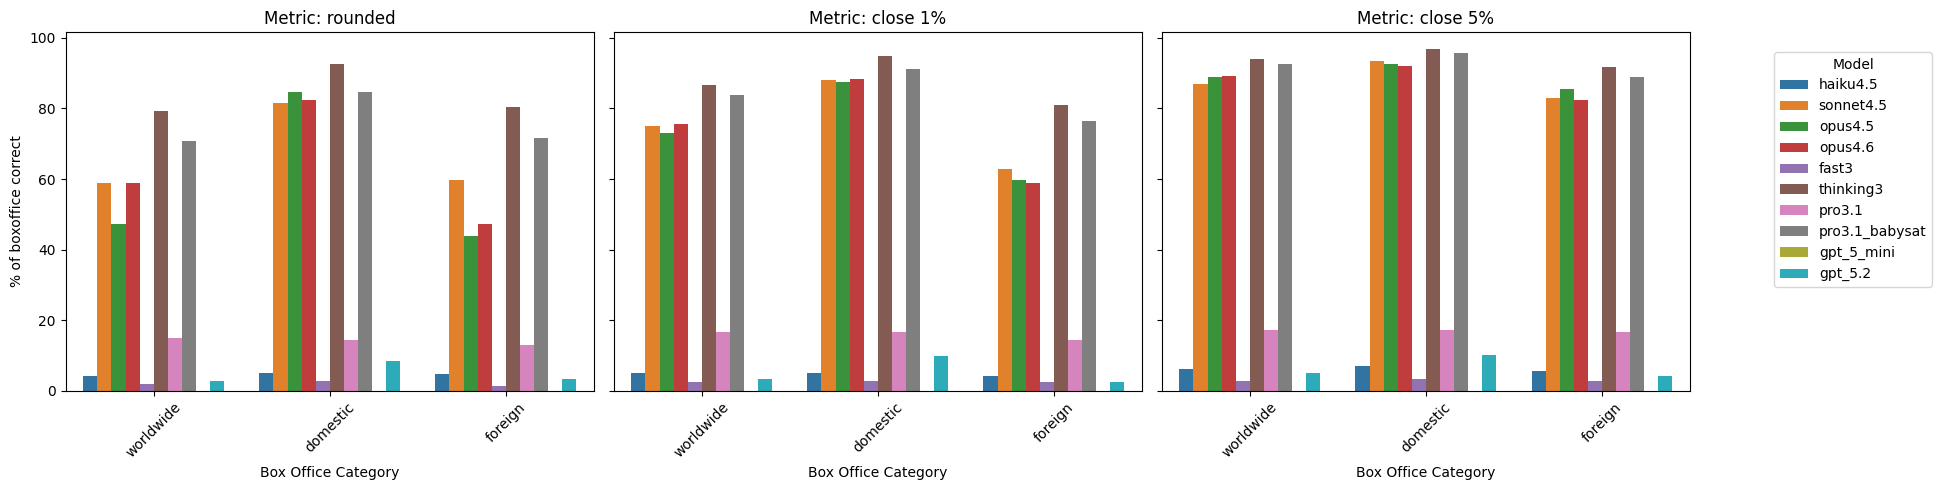

In [32]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, metric in enumerate(metric_order):
    sns.barplot(data=boxoffice_plot_df[boxoffice_plot_df['metric'] == metric], x='category', y='value', hue='model', ax=axes[i])
    axes[i].set_title(f'Metric: {metric.replace("_", " ")}')
    axes[i].set_ylabel('% of boxoffice correct' if i == 0 else '')
    axes[i].set_xlabel('Box Office Category')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Model', loc='upper right', bbox_to_anchor=(1.08, 0.9))

plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to make space for legend
plt.show()
fig.savefig('boxoffice.png', dpi=600, bbox_inches='tight') 

In [ ]:
test_df = boxoffice_merges['opus4.5']
test_df['round_equal'] = test_df['worldwide_round_student'] == test_df['worldwide_round_eval']
test_df['isclose_domestic'] = is_close(test_df['worldwide_student'] == test_df['worldwide_eval']
test_df.groupby('round_equal')['year'].mean()

round_equal
False    2013.192982
True     2009.617647
Name: year, dtype: Float64

In [43]:
test_df.query('round_equal == False')

,year,title,domestic_student,foreign_student,worldwide_student,worldwide_round_student,domestic_round_student,foreign_round_student,worldwide_eval,domestic_eval,foreign_eval,worldwide_round_eval,domestic_round_eval,foreign_round_eval,round_equal
0,2000,gladiator,187.7,277.8,465.5,466,188,278,460.584,187.705,272.879,461,188,273,False
2,2000,erin brockovich,125.6,132.3,257.9,258,126,132,256.271,125.595,130.676,256,126,131,False
14,2001,in the bedroom,35.9,8.1,44.0,44,36,8,43.369,35.931,7.438,43,36,7,False
15,2001,iris,5.6,11.8,17.4,17,6,12,16.154,5.595,10.559,16,6,11,False
23,2002,far from heaven,15.8,6.1,21.9,22,16,6,29.028,15.902,13.126,29,16,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,2024,conclave,32.6,95.2,127.8,128,33,95,57.908,31.272,26.636,58,31,27,False
212,2024,anora,20.0,19.4,39.4,39,20,19,30.247,14.09,16.157,30,14,16,False
213,2024,a complete unknown,75.0,65.5,140.5,140,75,66,25.68,25.68,0.0,26,26,0,False
214,2024,i'm still here,4.3,22.9,27.2,27,4,23,11.1,0.0,11.1,11,0,11,False


## VES awards

### Load data

In [20]:
ves_pdf = pd.read_csv(eval_loc + 'ves_awards/golden_set_ves_classified.tsv', sep = '\t')
ves_eval_cols = ['year', 'title', '# of nominations', 'outstanding']
ves_eval_pdf = ves_pdf.query('media_type == "film" and year >= 2019 and year <= 2024')[ves_eval_cols]
ves_eval_pdf = clean_award_data(ves_eval_pdf)

In [21]:
data = {}
data['haiku4.5']= pd.read_csv(eval_loc + 'ves_awards/claude_haiku_45_ves_y6.tsv', sep = '\t').query('year >= 2019 and year <=2024')
data['haiku4.5\nthinking']= pd.read_csv(eval_loc + 'ves_awards/claude_haiku_thinking_45_ves_y6.tsv', sep = '\t').query('year >= 2019 and year <=2024')
data['opus4.5'] = pd.read_csv(eval_loc + 'ves_awards/claude_opus_45_ves_y6.tsv', sep = '\t').query('year >= 2019 and year <=2024')
data['opus4.6'] = pd.read_csv(eval_loc + 'ves_awards/claude_opus_46_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['opus4.6']['year'] -= 1
data['sonnet4'] = pd.read_csv(eval_loc + 'ves_awards/claude_sonnet_thinking_4_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['sonnet4']['year'] -= 1
data['sonnet4.5'] = pd.read_csv(eval_loc + 'ves_awards/claude_sonnet_thinking_45_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['sonnet4.5']['year'] -= 1
data['flash3'] = pd.read_csv(eval_loc + 'ves_awards/gemini_flash_3_deep_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['flash3']['year'] -= 1
data['thinking3'] = pd.read_csv(eval_loc + 'ves_awards/gemini_thinking_3_deep_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['thinking3']['year'] -= 1
data['pro3.1'] = pd.read_csv(eval_loc + 'ves_awards/gemini_pro_31_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['pro3.1']['year'] -= 1
data['mini5'] = pd.read_csv(eval_loc + 'ves_awards/gpt_mini_5_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['gpt5.3'] = pd.read_csv(eval_loc + 'ves_awards/gpt_53_ves_y6.tsv', sep = '\t').query('year >= 2019')
data['gpt5.3']['year'] -= 1

In [22]:
for model, df in data.items():
    df = clean_award_data(df)
    if '# of nominations' in df.columns:
        df['# of nominations'] = df['# of nominations'].fillna(0).astype(pd.Int64Dtype(), errors = 'ignore')
    data[model] = df

In [23]:
merges = {}
for model in data:
    merges[model] = data[model].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes = ('_student', '_eval'))

### Eval

In [24]:
ves_default = {'nom_count': 0.0, 'outstanding': 0.0}
ves_evals = {model: copy.deepcopy(ves_default) for model in merges}

In [25]:
for model, merge_df in merges.items():
    ves_evals[model]['nom_count'] = (merge_df['# of nominations_eval'] == merge_df['# of nominations_student']).sum() / len(merge_df)
    ves_evals[model]['outstanding'] = (merge_df['outstanding_eval'] == merge_df['outstanding_student']).sum() / ves_eval_pdf['outstanding'].notnull().sum()

In [26]:
ves_plot_df = pd.DataFrame(ves_evals).T.reset_index()
ves_plot_df.columns = ['model', 'nom_count', 'outstanding']
ves_plot_df = ves_plot_df.query('nom_count > 0 or outstanding > 0')
ves_plot_df['provider']= ves_plot_df['model'].apply(get_provider)
ves_plot_df['color'] = ves_plot_df['provider'].map(provider_colors)
ves_plot_df['size']= ves_plot_df['model'].apply(get_size)
ves_plot_df = ves_plot_df.sort_values(['provider', 'size', 'model'])
ves_plot_df['nom_count']*=100
ves_plot_df['outstanding']*=100

### Graph

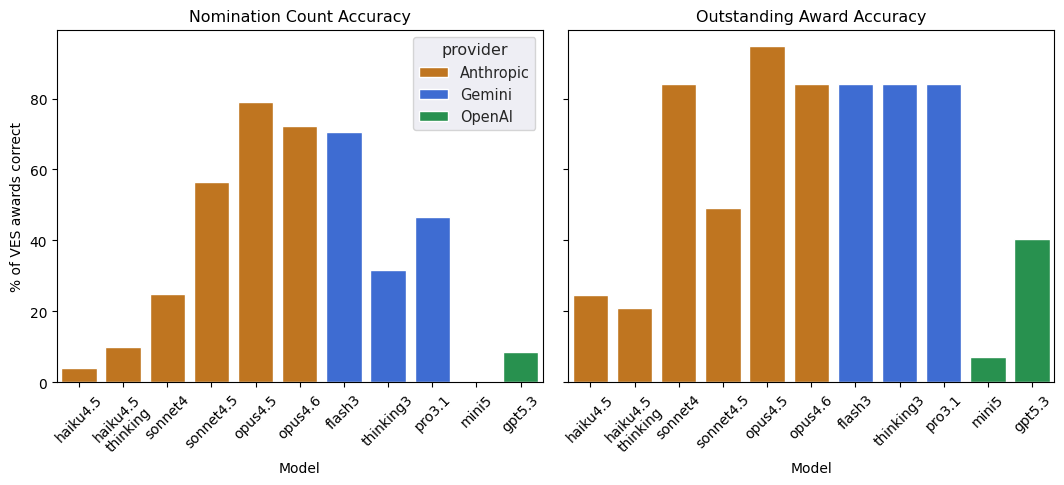

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.set(font_scale=0.95)

sns.barplot(data=ves_plot_df, x='model', y='nom_count', hue='provider', palette=provider_colors, dodge=False, ax=axes[0])
#sns.barplot(data=ves_plot_df, x='model', y='nom_count', ax=axes[0], hue=ves_plot_df['color'])
axes[0].set_title('Nomination Count Accuracy')
axes[0].set_ylabel('% of VES awards correct')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)
#axes[0].get_legend().remove()

sns.barplot(data=ves_plot_df, x='model', y='outstanding', hue='provider', palette=provider_colors, dodge=False, ax=axes[1])
axes[1].set_title('Outstanding Award Accuracy')
axes[1].set_ylabel('')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, title='Provider', loc='upper right', bbox_to_anchor=(1.02, 0.9))

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()
fig.savefig('VES_nominations.png', dpi=600, bbox_inches='tight') 

## Earnings

### Load data and merge

In [28]:
earnings_pdf = pd.read_csv(eval_loc + 'earnings_transcripts/golden_set_earnings.tsv', sep = '\t')
earnings_eval_pdf = earnings_pdf.query('quarter >="2021Q1"')

In [29]:
earnings_data = {}
earnings_data['haiku4.6'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_haiku_46_earnings_y6.tsv', sep = '\t')
earnings_data['haiku4.6_research'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_haiku_research_46_earnings_y6.tsv', sep = '\t')
earnings_data['sonnet4.6_research'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_sonnet_research_46_earnings_y6.tsv', sep = '\t')
earnings_data['opus4.5'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_opus_45_earnings_y6.tsv', sep = '\t')
earnings_data['opus4.6'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_opus_4.6_earnings_y6.tsv', sep = '\t')
earnings_data['fast3'] = pd.read_csv(eval_loc + 'earnings_transcripts/gemini_fast_3_earnings_y6.tsv', sep = '\t')
earnings_data['fast3_deep'] = pd.read_csv(eval_loc + 'earnings_transcripts/gemini_fast_deep_3_earnings.tsv', sep = '\t')
earnings_data['pro3.1_research'] = pd.read_csv(eval_loc + 'earnings_transcripts/gemini_pro_research_3_earnings_y6.tsv', sep = '\t')
earnings_data['gpt5.3'] = pd.read_csv(eval_loc + 'earnings_transcripts/gpt_53_earnings_y6.tsv', sep = '\t')

In [30]:
earnings_merges = {}

for model in earnings_data.keys():
    print(model)
    earnings_merges[model] = (earnings_data[model].merge(earnings_eval_pdf, on = 'quarter',
                                                        how='right', suffixes = ('_student', '_eval')))

haiku4.6
haiku4.6_research
sonnet4.6_research
opus4.5
opus4.6
fast3
fast3_deep
pro3.1_research
gpt5.3


### Evals

In [55]:
stat_default = {'exact': {'ai_all':0.0, 'ai_meta':0.0, 'metaverse_all':0.0, 'metaverse_meta':0.0, 'reels_all':0.0, 'reels_meta':0.0},
                'close_10%':{'ai_all':0.0, 'ai_meta':0.0, 'metaverse_all':0.0, 'metaverse_meta':0.0, 'reels_all':0.0, 'reels_meta':0.0},
                'close_20%':{'ai_all':0.0, 'ai_meta':0.0, 'metaverse_all':0.0, 'metaverse_meta':0.0, 'reels_all':0.0, 'reels_meta':0.0},
                'higher':{'ai_all':0.0, 'ai_meta':0.0, 'metaverse_all':0.0, 'metaverse_meta':0.0, 'reels_all':0.0, 'reels_meta':0.0},
                    }
earnings_evals = { }
for model in earnings_merges.keys():
    earnings_evals[model] = copy.deepcopy(stat_default)
earnings_cols = ['ai_all',	'ai_meta',	'metaverse_all'	,'metaverse_meta',	'reels_all', 'reels_meta']
for col in earnings_cols:
    for model in earnings_merges.keys():
        earnings_evals[model]['exact'][col] =( earnings_merges[model][col + '_student'] == earnings_merges[model][col + '_eval']).sum() / len(earnings_merges[model])
        earnings_evals[model]['close_10%'][col] = is_close( earnings_merges[model][col + '_student'],  earnings_merges[model][col + '_eval'], 0.1).sum() / len(earnings_merges[model])
        
        earnings_evals[model]['close_20%'][col] = is_close( earnings_merges[model][col + '_student'],  earnings_merges[model][col + '_eval'], 0.2).sum() / len(earnings_merges[model])
        earnings_evals[model]['higher'][col] = (earnings_merges[model][col + '_student'] > earnings_merges[model][col + '_eval']).mean()

In [56]:
earnings_evals_pdf = pd.concat([pd.DataFrame(eval).assign(model = model) for model, eval in earnings_evals.items()]).reset_index()
earnings_evals_pdf.columns = ['token_type', 'exact','close_10%', 'close_20%', 'higher', 'model']
earnings_evals_pdf.sample(3)

,token_type,exact,close_10%,close_20%,higher,model
1,ai_meta,0.00,0.05,0.2,0.20,haiku4.6
36,ai_all,0.00,0.00,0.0,1.00,fast3_deep
12,ai_all,0.05,0.45,0.6,0.35,sonnet4.6_research


In [57]:
earnings_evals_plot_pdf = pd.melt(earnings_evals_pdf, id_vars = ['model', 'token_type'], value_vars = ['exact', 'close_10%', 'close_20%', 'higher'], var_name = 'metric', value_name = 'value')

earnings_evals_plot_pdf['provider']= earnings_evals_plot_pdf['model'].apply(get_provider)
earnings_evals_plot_pdf['color'] = earnings_evals_plot_pdf['provider'].map(provider_colors)
earnings_evals_plot_pdf['size']= earnings_evals_plot_pdf['model'].apply(get_size)
earnings_evals_plot_pdf = earnings_evals_plot_pdf.sort_values(['provider', 'size'])
earnings_evals_plot_pdf['value']*=100
earnings_evals_plot_pdf.sample(2)

,model,token_type,metric,value,provider,color,size
3,haiku4.6,metaverse_meta,exact,10.0,Anthropic,#D97706,0
196,fast3,reels_all,higher,40.0,Gemini,#2563EB,0


### Graph

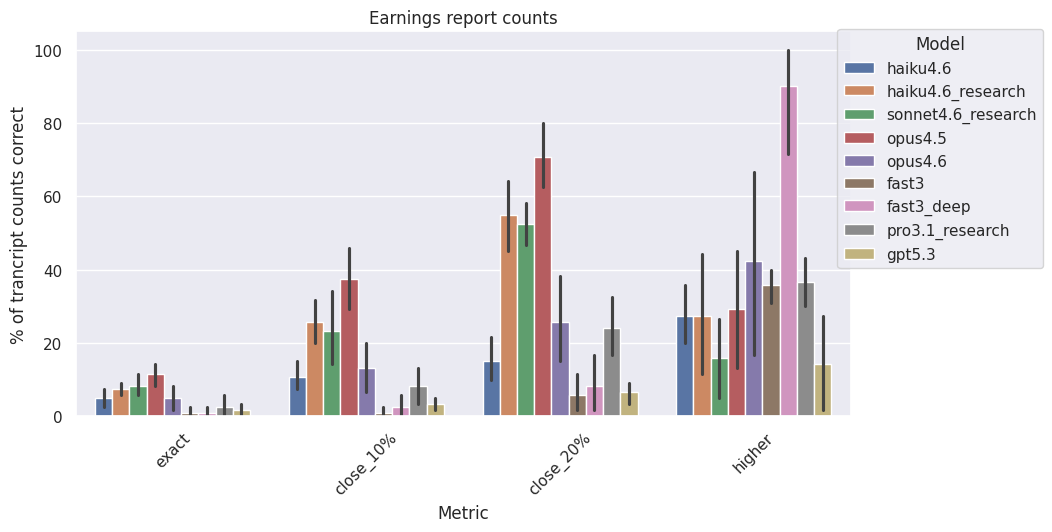

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=earnings_evals_plot_pdf, hue='model', y='value', x='metric'
           )
ax.set_ylabel('% of trancript counts correct')
ax.set_xlabel('Metric')
ax.set_title('Earnings report counts')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Provider')
ax.get_legend().remove()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Model', loc='upper right', bbox_to_anchor=(1.1, 0.9))

fig.savefig('earnings.png', dpi=600, bbox_inches='tight') 

In [34]:
earnings_summary_pdf = earnings_evals_plot_pdf.groupby(['model', 'provider', 'size'])['value'].mean().reset_index().sort_values(['provider', 'size'])
earnings_summary_pdf

,model,provider,size,value
3,haiku4.6,Anthropic,0,10.277778
4,haiku4.6_research,Anthropic,0,29.444444
8,sonnet4.6_research,Anthropic,1,28.055556
5,opus4.5,Anthropic,2,40.000000
6,opus4.6,Anthropic,2,14.722222
0,fast3,Gemini,0,2.500000
1,fast3_deep,Gemini,0,3.888889
7,pro3.1_research,Gemini,Other,11.666667
2,gpt5.3,OpenAI,2,3.888889


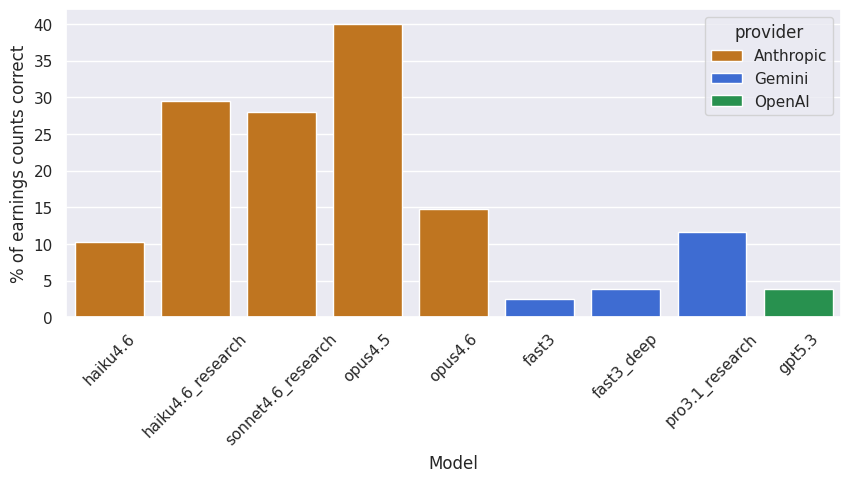

In [35]:
sns.set(font_scale=1)
fig, ax = plt.subplots(1, figsize = [10, 4])

sns.barplot(earnings_summary_pdf, x = 'model', y = 'value', hue = 'provider',palette=provider_colors,)
ax.tick_params(axis='x', rotation=45)
plt.ylabel('% of earnings counts correct')
plt.xlabel('Model')
fig.savefig('earnings_summary.png', dpi = 600, bbox_inches = 'tight')

# Combine scores into one

## Munge data

In [78]:
gg_plot_df = gg_plot_df.rename(columns = {'accuracy':'gg_accuracy'})

In [79]:
boxoffice_by_model_pdf = pd.DataFrame(boxoffice_plot_df.groupby('model')['value'].mean()).reset_index()
boxoffice_by_model_pdf.columns = ['model', 'boxoffice_accuracy']

In [80]:
ves_by_model_pdf = pd.DataFrame(ves_plot_df.groupby('model')[['nom_count', 'outstanding']].mean().mean(axis=1)).reset_index()
ves_by_model_pdf.columns = ['model', 'ves_accuracy']
ves_by_model_pdf

,model,ves_accuracy
0,flash3,77.399381
1,gpt5.3,24.451754
2,haiku4.5,14.254386
3,haiku4.5\nthinking,15.460526
4,mini5,3.508772
5,opus4.5,86.842105
6,opus4.6,78.289474
7,pro3.1,65.460526
8,sonnet4,54.605263
9,sonnet4.5,52.850877


In [81]:
earnings_by_model_pdf = pd.DataFrame(earnings_evals_plot_pdf.groupby('model')['value'].mean()).reset_index()
earnings_by_model_pdf.columns = ['model', 'earnings_accuracy']
earnings_by_model_pdf

,model,earnings_accuracy
0,fast3,1.785714
1,fast3_deep,3.968254
2,gpt5.3,7.539683
3,haiku4.6,9.523810
4,haiku4.6_research,33.928571
5,opus4.5,41.468254
6,opus4.6,15.277778
7,pro3.1_research,10.912698
8,sonnet4.6_research,34.126984


In [82]:
def normalize_model(name):
    name = str(name).lower()
    if 'haiku' in name:    return 'haiku'
    if 'sonnet' in name:   return 'sonnet'
    if 'opus' in name:     return 'opus'
    if 'flash' in name or 'fast' in name: return 'fast/flash'
    if 'thinking' in name: return 'thinking'
    if 'pro' in name:      return 'pro'
    if 'mini' in name:     return 'mini'
    if 'gpt' in name:      return 'gpt'
    return name

def norm_and_agg(df, value_col):
    return (df.assign(model=df['model'].apply(normalize_model))
              .groupby('model', as_index=False)[value_col].max())

combined_df = (norm_and_agg(gg_plot_df, 'gg_accuracy')
               .merge(norm_and_agg(boxoffice_by_model_pdf, 'boxoffice_accuracy'), on='model', how='outer')
               .merge(norm_and_agg(ves_by_model_pdf, 'ves_accuracy'), on='model', how='outer')
               .merge(norm_and_agg(earnings_by_model_pdf, 'earnings_accuracy'), on='model', how='outer'))
combined_df

,model,gg_accuracy,boxoffice_accuracy,ves_accuracy,earnings_accuracy
0,fast/flash,97.570850,2.469136,77.399381,3.968254
1,gpt,32.388664,5.452675,24.451754,7.539683
2,haiku,14.574899,5.195473,15.460526,33.928571
3,mini,6.477733,0.000000,3.508772,NaN
4,opus,96.761134,75.000000,86.842105,41.468254
5,pro,99.190283,84.002058,65.460526,10.912698
6,sonnet,96.356275,76.594650,54.605263,34.126984
7,thinking,96.356275,88.580247,57.894737,NaN


## Graph

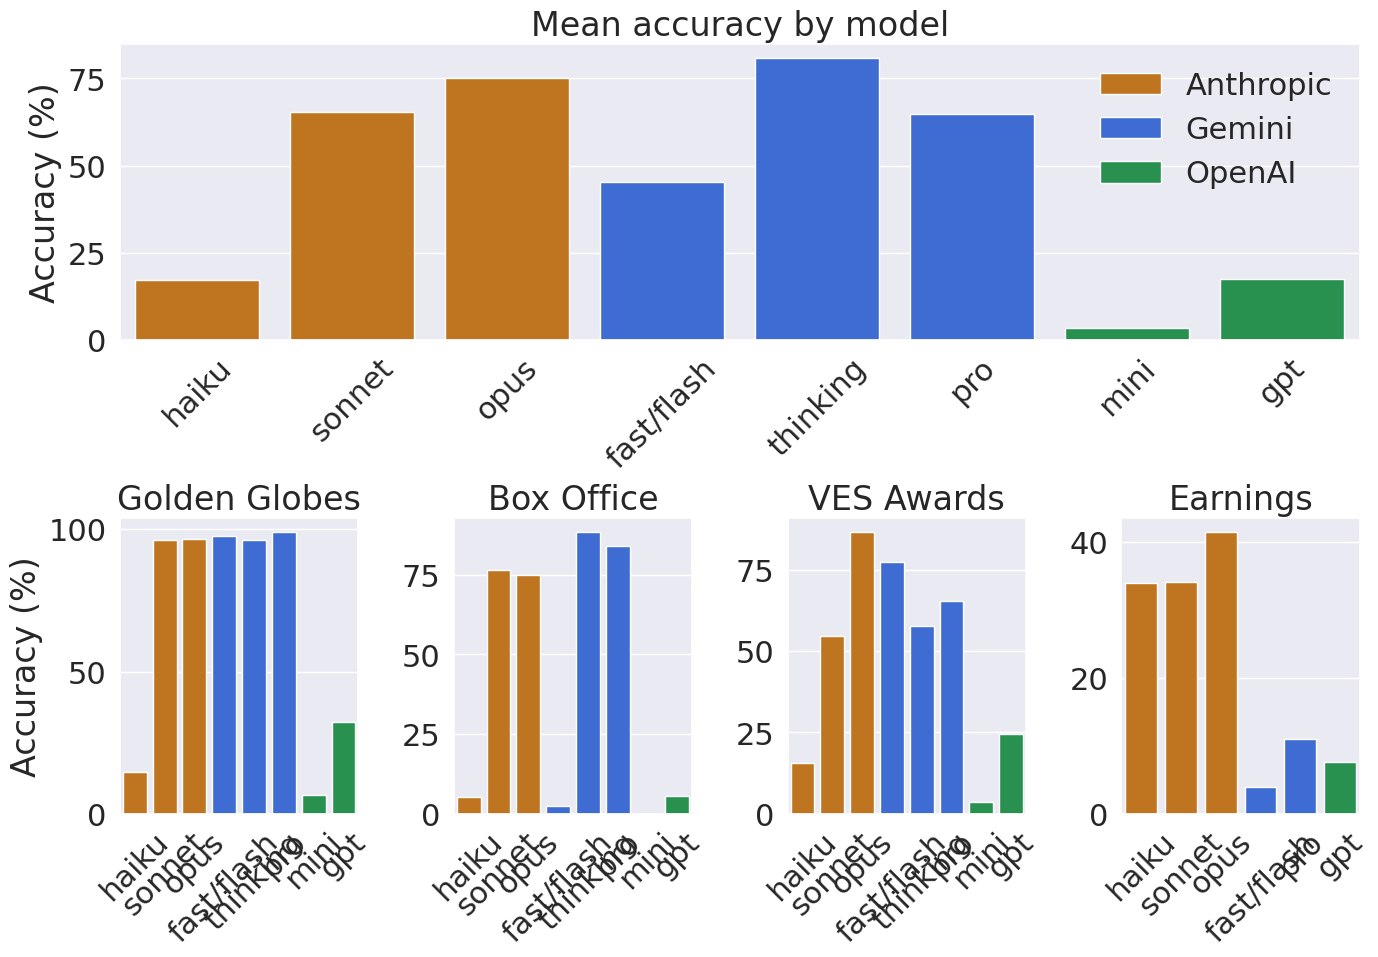

In [83]:
sns.set(font_scale=2)
eval_cols = ['gg_accuracy', 'boxoffice_accuracy', 'ves_accuracy', 'earnings_accuracy']
eval_labels = {
    'gg_accuracy':       'Golden Globes',
    'boxoffice_accuracy': 'Box Office',
    'ves_accuracy':      'VES Awards',
    'earnings_accuracy': 'Earnings',
}

combined_df['provider'] = combined_df['model'].apply(get_provider)
combined_df['size'] = combined_df['model'].apply(get_size)
combined_df['overall'] = combined_df[eval_cols].mean(axis=1)
combined_df = combined_df.sort_values(['provider', 'size'])

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 4, hspace=0.6, wspace=0.4)

# Top: overall average spanning full width
ax_top = fig.add_subplot(gs[0, :])
sns.barplot(data=combined_df, x='model', y='overall',
            hue='provider', palette=provider_colors, dodge=False, ax=ax_top)
ax_top.set_title('Mean accuracy by model')
ax_top.set_ylabel('Accuracy (%)')
ax_top.set_xlabel('')

ax_top.tick_params(axis='x', rotation=45)
ax_top.legend(frameon=False)

# Bottom: one subplot per eval
for i, (col, label) in enumerate(eval_labels.items()):
    ax = fig.add_subplot(gs[1, i])
    plot_data = combined_df.dropna(subset=[col])
    sns.barplot(data=plot_data, x='model', y=col,
                hue='provider', palette=provider_colors, dodge=False, ax=ax)
    ax.set_title(label)
    ax.set_ylabel('Accuracy (%)' if i == 0 else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.get_legend().remove()

fig.savefig('overall.png', dpi=600, bbox_inches='tight') 
plt.show()